# Designing the Scale

How many points, where to put them, and what the design must vary

Dan Yavorsky  
Geoffery Zheng  
September 14, 2026

## What this notebook does

The information results in the paper are abstract. This notebook turns them into three concrete decisions a researcher has to make before fielding a study.

1.  **How many scale points?** A binary follow-up is the least informative member of the family and a continuous report is the limit. Where between them does a five- or seven-point scale sit?
2.  **Where do the cut points fall?** Scale size is only half the problem. The labels a respondent sees determine where the thresholds land, and placement turns out to matter about as much as count, at least for one of the two links.
3.  **What must the design vary?** Separately from the scale, telling Model A from Model B requires the tasks to vary in attractiveness. This is a property of the design, not of the sample size, and the distinction has real consequences: a study can collect unlimited data and still learn nothing about the link.

The third result is the sharpest, and it is a negative one. It is also the cleanest empirical demonstration of the identification argument in the model section, since it shows exactly what is lost when the identifying variation is removed.

This notebook is the source of `link_discrimination.rds`, `link_discrimination_squashed.rds`, `design_guidance.rds`, and the figure the article displays.

In [ ]:
#| label: setup
set.seed(1)
options(digits = 5)

## 1. Machinery

In [ ]:
#| label: machinery
#| code-fold: true
#| code-summary: "Design, simulator, likelihood, and the information weight omega"
rgumbel <- function(n) -log(-log(runif(n)))
make_design <- function(n_tasks, J, seed, intercept = FALSE) {
  set.seed(seed)
  n_rows <- n_tasks * J
  a <- sample(1:3, n_rows, replace = TRUE); b <- sample(1:3, n_rows, replace = TRUE)
  price <- runif(n_rows, 0.5, 2.5)
  X <- cbind(a2 = as.numeric(a == 2), a3 = as.numeric(a == 3),
             b2 = as.numeric(b == 2), b3 = as.numeric(b == 3), price = price)
  if (intercept) X <- cbind(X, const = 1)
  list(X = X, n_tasks = n_tasks, J = J, P = ncol(X))
}
par_to_cut <- function(par, P, W) {
  if (W == 2) return(par[P + 1])
  par[P + 1] + c(0, cumsum(exp(par[(P + 2):(P + W - 1)])))
}
cut_to_par <- function(cut) if (length(cut) == 1) cut else c(cut[1], log(diff(cut)))
row_max <- function(M) do.call(pmax, as.data.frame(M))
link_cdf <- function(z, model) if (model == "B") plogis(z) else exp(-exp(-z))
link_pdf <- function(z, model) if (model == "B") dlogis(z) else exp(-(z + exp(-z)))
ord_prob_z <- function(lo, hi, model) {
  if (model == "B") plogis(hi) * plogis(-lo) * (-expm1(lo - hi))
  else { ea <- exp(-lo); eb <- exp(-hi)
         p <- exp(-eb) * (-expm1(-(ea - eb))); p[!is.finite(eb)] <- 0; p }
}
ord_prob <- function(mubar, cut, y, model) {
  caug <- c(-Inf, cut, Inf); ord_prob_z(caug[y] - mubar, caug[y + 1L] - mubar, model)
}
negloglik <- function(par, dat) {
  design <- dat$design; P <- design$P; W <- dat$W
  n <- design$n_tasks; J <- design$J
  beta <- par[1:P]; cut <- par_to_cut(par, P, W)
  V <- matrix(design$X %*% beta, nrow = n, ncol = J, byrow = TRUE)
  m <- row_max(V); logS <- m + log(rowSums(exp(V - m)))
  -(sum(V[cbind(seq_len(n), dat$jstar)] - logS) +
    sum(log(pmax(ord_prob(logS, cut, dat$y, dat$model), 1e-312))))
}
fit_dual_mle <- function(dat, start = NULL) {
  design <- dat$design; P <- design$P; W <- dat$W
  if (is.null(start)) {
    freq <- tabulate(dat$y, nbins = W)
    cumq <- pmin(pmax(cumsum(freq)[1:(W - 1)] / sum(freq), 1e-4), 1 - 1e-4)
    ginv <- if (dat$model == "B") qlogis else function(q) -log(-log(q))
    cut0 <- log(design$J) + ginv(cumq)
    if (W > 2) for (k in 2:(W - 1)) cut0[k] <- max(cut0[k], cut0[k - 1] + 1e-3)
    start <- c(rep(0, P), cut_to_par(cut0))
  }
  fn <- function(p) negloglik(p, dat)
  opt <- optim(start, fn, method = "BFGS", control = list(maxit = 1000, reltol = 1e-12))
  H <- optimHess(opt$par, fn)
  list(beta = opt$par[1:P], cut = par_to_cut(opt$par, P, W), nll = opt$value,
       par = opt$par, eigen = eigen(H, symmetric = TRUE, only.values = TRUE)$values)
}
simulate_dual <- function(design, beta, cut, model = c("A","B"), seed) {
  model <- match.arg(model); set.seed(seed)
  n <- design$n_tasks; J <- design$J
  V <- matrix(design$X %*% beta, nrow = n, ncol = J, byrow = TRUE)
  u <- V + matrix(rgumbel(n * J), n, J)
  jstar <- max.col(u, ties.method = "first")
  ustar <- u[cbind(seq_len(n), jstar)]
  latent <- if (model == "A") ustar else ustar - rgumbel(n)
  list(design = design, jstar = jstar, y = findInterval(latent, cut) + 1L,
       W = length(cut) + 1L, model = model)
}
# The second-stage information weight from the paper's decomposition.
omega_weight <- function(mubar, cut, model) {
  z <- outer(mubar, cut, function(m, c) c - m)
  Gz <- cbind(0, link_cdf(z, model), 1); gz <- cbind(0, link_pdf(z, model), 0)
  W <- length(cut) + 1L
  om <- 0
  for (w in seq_len(W)) om <- om + (gz[, w + 1] - gz[, w])^2 / (Gz[, w + 1] - Gz[, w])
  om
}

In [ ]:
#| label: config
J <- 4; W <- 5
beta   <- c(a2 = 0.8, a3 = -0.5, b2 = 0.4, b3 = 1.0, price = -0.9)
cutB   <- c(-1.0, 0.2, 1.2, 2.2)
alphaA <- c(0.10, 0.30, 0.60, 0.85)
cutA   <- -log(-log(alphaA))
TAU2   <- 100
R_REPS <- 60

## 2. How many scale points?

The quantity to maximize is $\omega$, the second response’s contribution to the information matrix. It has a ceiling: the information a *continuous* report of the latent would carry, which is $1$ for the Gumbel link and $1/3$ for the logistic. Every finite scale is a partition of that continuum, and refining the partition can only add information.

In [ ]:
#| label: info-by-w
I_LATENT <- c(A = 1, B = 1/3)

mean_omega <- function(cut, model, m0, s, ngrid = 81) {
  z <- seq(-4, 4, length.out = ngrid); w <- dnorm(z); w <- w / sum(w)
  sum(w * omega_weight(m0 + s * z, cut, model))
}

# Cut points giving every category the same expected share.
equal_share_cuts <- function(W, model, m0, s) {
  qs <- seq_len(W - 1) / W
  G <- if (model == "B") function(c, m) plogis(c - m) else
                          function(c, m) exp(-exp(-(c - m)))
  f <- function(c) integrate(function(m) G(c, m) * dnorm(m, m0, s),
                             m0 - 6*s - 10, m0 + 6*s + 10)$value
  vapply(qs, function(q) uniroot(function(c) f(c) - q, c(m0 - 20, m0 + 20))$root,
         numeric(1))
}

REGIMES <- list(unattractive = -1.5, typical = 0.6, attractive = 2.3)
SPREAD  <- 0.5
WGRID   <- c(2, 3, 5, 7, 9, 11)

tab_w <- do.call(rbind, lapply(names(REGIMES), function(rg) {
  m0 <- REGIMES[[rg]]
  do.call(rbind, lapply(c("A","B"), function(model) {
    do.call(rbind, lapply(WGRID, function(Wk) {
      cuts <- equal_share_cuts(Wk, model, m0, SPREAD)
      om <- mean_omega(cuts, model, m0, SPREAD)
      data.frame(regime = rg, model = model, W = Wk, omega = om,
                 frac = om / I_LATENT[model])
    }))
  }))
}))

knitr::kable(
  reshape(tab_w[, c("regime","model","W","frac")], direction = "wide",
          idvar = c("model","W"), timevar = "regime"),
  row.names = FALSE, digits = 3)

  model      W   frac.unattractive   frac.typical   frac.attractive
  ------- ---- ------------------- -------------- -----------------
  A          2               0.463          0.463             0.463
  A          3               0.634          0.634             0.634
  A          5               0.777          0.777             0.777
  A          7               0.840          0.840             0.840
  A          9               0.875          0.875             0.875
  A         11               0.898          0.898             0.898
  B          2               0.708          0.708             0.708
  B          3               0.865          0.865             0.865
  B          5               0.950          0.950             0.950
  B          7               0.974          0.974             0.974
  B          9               0.984          0.984             0.984
  B         11               0.990          0.990             0.990


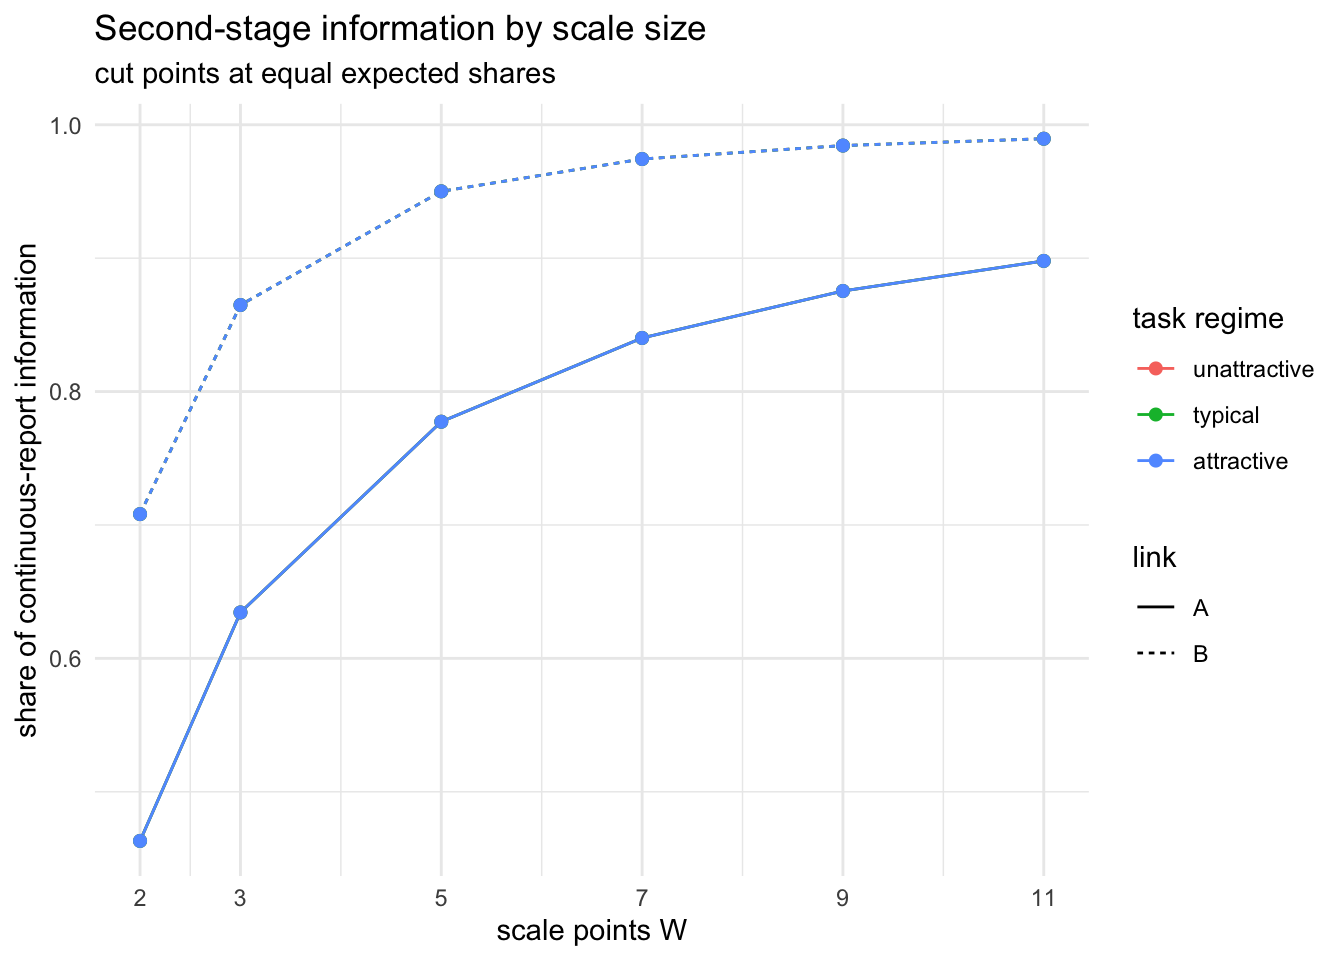

In [ ]:
#| label: fig-infoW
#| fig-cap: "Share of the continuous-report information captured by a W-point second response, cut points at equal expected shares."
suppressMessages(library(ggplot2))
tab_w$regime <- factor(tab_w$regime, levels = names(REGIMES))
g1 <- ggplot(tab_w, aes(W, frac, colour = regime, linetype = model)) +
  geom_line() + geom_point(size = 1.8) +
  scale_x_continuous(breaks = WGRID) +
  labs(x = "scale points W", y = "share of continuous-report information",
       colour = "task regime", linetype = "link",
       title = "Second-stage information by scale size",
       subtitle = "cut points at equal expected shares") +
  theme_minimal(base_size = 11)
g1

The shape is the finding. Going from two points to five closes most of the gap to a continuous report; going from seven to eleven adds very little. A binary follow-up is not merely *a* choice of scale, it is the least informative one available, and the first few extra categories are nearly free.

## 3. Where should the cut points fall?

Scale size is the decision researchers discuss. Placement is the one they make implicitly, by choosing labels. Compare three placements at $W = 5$: the information-optimal one, equal expected shares, and a “conventional label” placement reproducing the bottom-heavy distribution fielded purchase-intent scales actually produce.

In [ ]:
#| label: placement
optimal_cuts <- function(W, model, m0, s) {
  start <- equal_share_cuts(W, model, m0, s)
  if (W == 2) {
    opt <- optimize(function(c) -mean_omega(c, model, m0, s),
                    interval = c(m0 - 8, m0 + 8))
    return(list(cut = opt$minimum, omega = -opt$objective))
  }
  fn <- function(p) -mean_omega(p[1] + c(0, cumsum(exp(p[-1]))), model, m0, s)
  opt <- optim(c(start[1], log(diff(start))), fn, method = "BFGS",
               control = list(maxit = 500))
  list(cut = opt$par[1] + c(0, cumsum(exp(opt$par[-1]))), omega = -opt$value)
}

placements <- list()
for (model in c("A","B")) {
  m0 <- REGIMES$typical
  eq <- equal_share_cuts(5, model, m0, SPREAD)
  op <- optimal_cuts(5, model, m0, SPREAD)
  G <- if (model == "B") function(c, m) plogis(c - m) else
                          function(c, m) exp(-exp(-(c - m)))
  conv_shares <- cumsum(c(0.35, 0.23, 0.23, 0.12))
  conv <- vapply(conv_shares, function(q) uniroot(function(c)
    integrate(function(m) G(c, m) * dnorm(m, m0, SPREAD),
              m0 - 13, m0 + 13)$value - q, c(m0 - 20, m0 + 20))$root, numeric(1))
  om <- c(optimal = op$omega,
          equal_share = mean_omega(eq, model, m0, SPREAD),
          conventional = mean_omega(conv, model, m0, SPREAD),
          binary_opt = optimal_cuts(2, model, m0, SPREAD)$omega)
  placements[[model]] <- list(optimal = op$cut, equal = eq,
                              conventional = conv, omega = om)
}

knitr::kable(do.call(rbind, lapply(c("A","B"), function(mm) {
  om <- placements[[mm]]$omega
  data.frame(link = mm, optimal = round(om[1], 4),
             `equal share` = sprintf("%.4f (%.0f%%)", om[2], 100*om[2]/om[1]),
             conventional = sprintf("%.4f (%.0f%%)", om[3], 100*om[3]/om[1]),
             `best binary` = sprintf("%.4f (%.0f%%)", om[4], 100*om[4]/om[1]),
             check.names = FALSE)})), row.names = FALSE)

  link     optimal equal share     conventional   best binary
  ------ --------- --------------- -------------- --------------
  A         0.8940 0.7774 (87%)    0.6367 (71%)   0.5693 (64%)
  B         0.3169 0.3167 (100%)   0.3052 (96%)   0.2361 (74%)


The two links behave differently, and the difference is practical. For the logistic link placement barely matters: equal shares is close to optimal. For the Gumbel link it matters, because the Gumbel density is asymmetric and the information is concentrated where it is steep. Conventional labels, which push mass toward the bottom of the scale, cost real information under both links.

The bottom row is the one to keep in mind: even the *best possible* binary cut sits far below a five-point scale. Choosing the scale well cannot rescue a scale that is too coarse.

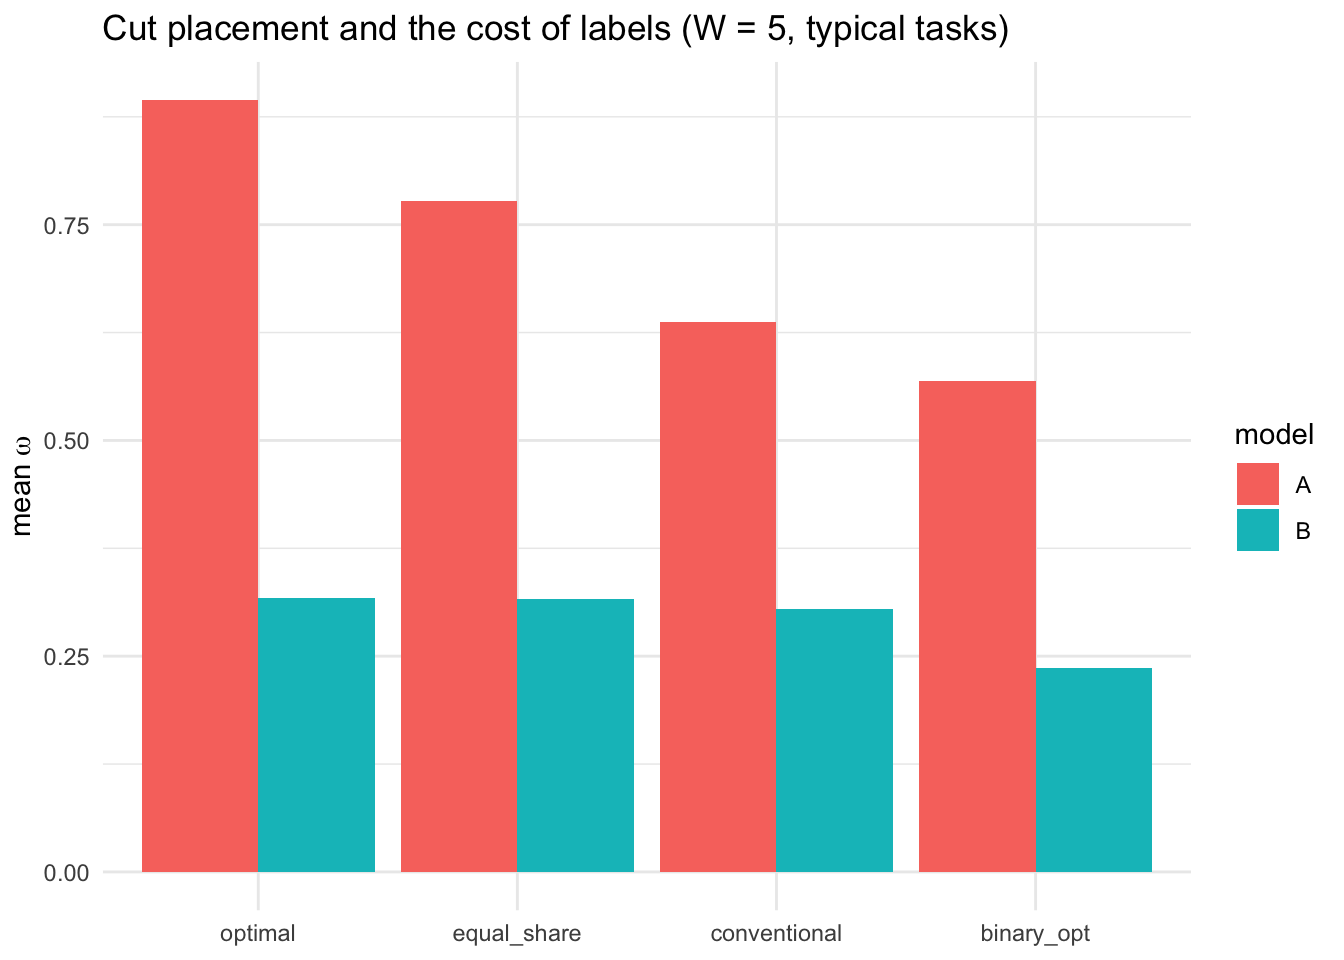

In [ ]:
#| label: fig-placement
#| fig-cap: "Cut placement and the cost of conventional labels at W = 5."
om_tab <- do.call(rbind, lapply(names(placements), function(mm)
  data.frame(model = mm, placement = names(placements[[mm]]$omega),
             omega = as.numeric(placements[[mm]]$omega))))
om_tab$placement <- factor(om_tab$placement,
  levels = c("optimal","equal_share","conventional","binary_opt"))
ggplot(om_tab, aes(placement, omega, fill = model)) +
  geom_col(position = "dodge") +
  labs(x = NULL, y = expression(mean~omega),
       title = "Cut placement and the cost of labels (W = 5, typical tasks)") +
  theme_minimal(base_size = 11)

## 4. What the design must vary

Now a different question. Scale design controls how much information the second response carries *about the parameters*. It does not control whether the data can tell Model A from Model B. That depends on how much the tasks vary in attractiveness.

The reason is the identification argument in the model section. At a single value of $\overline{\mu}$, any two strictly increasing links reproduce the $W$ category frequencies exactly by relabelling cut points. Only variation in $\overline{\mu}$ separates them, because the two links disagree about how the response distribution should *move* as tasks get better or worse.

We manipulate that variation directly. A task-level shift added to every alternative’s price moves the whole task’s inclusive value, and because it lives in the price column rather than a new constant, the design stays identified in the rank-condition sense.

In [ ]:
#| label: link-disc
make_spread_design <- function(n_tasks, seed, sigma_task) {
  des <- make_design(n_tasks, J, seed = seed)
  if (sigma_task > 0) {
    s_t <- rnorm(n_tasks, 0, sigma_task)
    des$X[, "price"] <- des$X[, "price"] + rep(s_t, each = J)
  }
  des
}
laplace_lmd <- function(fit) {
  d <- length(fit$par)
  -fit$nll - 0.5*sum(fit$par^2)/TAU2 - 0.5*d*log(2*pi*TAU2) +
    0.5*d*log(2*pi) - 0.5*sum(log(fit$eigen))
}

run_cell <- function(sigma_task, n_tasks, reps, seed0) {
  correct_lmd <- correct_hll <- matrix(NA, reps, 2,
                                       dimnames = list(NULL, c("A","B")))
  musd <- numeric(reps)
  for (r in seq_len(reps)) {
    des <- make_spread_design(n_tasks, seed = seed0 + 11*r, sigma_task)
    n_hold <- floor(0.2 * n_tasks)
    keep <- seq_len(n_tasks) > n_hold
    subdes <- function(kv) { d2 <- des; d2$X <- des$X[rep(kv, each = J), , drop = FALSE]
                             d2$n_tasks <- sum(kv); d2 }
    des_est <- subdes(keep); des_hold <- subdes(!keep)
    for (truth in c("A","B")) {
      cut_true <- if (truth == "A") cutA else cutB
      dat_full <- simulate_dual(des, as.numeric(beta), cut_true, model = truth,
                                seed = seed0 + 11*r + 1)
      musd[r] <- sd(log(rowSums(exp(matrix(des$X %*% beta, ncol = J, byrow = TRUE)))))
      dat_est  <- list(design = des_est,  jstar = dat_full$jstar[keep],
                       y = dat_full$y[keep], W = W, model = "A")
      dat_hold <- list(design = des_hold, jstar = dat_full$jstar[!keep],
                       y = dat_full$y[!keep], W = W, model = "A")
      lmd <- hll <- c(A = NA_real_, B = NA_real_)
      for (fl in c("A","B")) {
        dat_est$model <- fl; dat_hold$model <- fl
        f <- fit_dual_mle(dat_est)
        lmd[fl] <- laplace_lmd(f)
        hll[fl] <- -negloglik(f$par, dat_hold)
      }
      correct_lmd[r, truth] <- names(which.max(lmd)) == truth
      correct_hll[r, truth] <- names(which.max(hll)) == truth
    }
  }
  list(sigma_task = sigma_task, n = n_tasks, mubar_sd = mean(musd),
       lmd = colMeans(correct_lmd), hll = colMeans(correct_hll))
}

ld_cells <- list(); seed0 <- 100000
for (sig in c(0, 0.75, 1.5)) for (n in c(1800, 3600, 7200)) {
  seed0 <- seed0 + 5000
  ld_cells[[sprintf("sig%.2f_n%d", sig, n)]] <- run_cell(sig, n, R_REPS, seed0)
}

In [ ]:
#| label: link-disc-table
knitr::kable(do.call(rbind, lapply(ld_cells, function(cl) data.frame(
  `sigma task` = cl$sigma_task, n = cl$n,
  `mubar sd` = round(cl$mubar_sd, 2),
  `P(correct | A)` = round(cl$lmd["A"], 2),
  `P(correct | B)` = round(cl$lmd["B"], 2),
  `holdout: A` = round(cl$hll["A"], 2),
  `holdout: B` = round(cl$hll["B"], 2),
  check.names = FALSE))), row.names = FALSE)

  -------------------------------------------------------------------------------
     sigma      n   mubar  P(correct \| A)  P(correct \| B) holdout: A holdout: B
      task             sd                                              
  -------- ------ ------- ---------------- ---------------- ---------- ----------
      0.00   1800    0.47                1                1       0.98       0.92

      0.00   3600    0.47                1                1       1.00       1.00

      0.00   7200    0.47                1                1       1.00       0.98

      0.75   1800    0.82                1                1       1.00       0.98

      0.75   3600    0.82                1                1       1.00       1.00

      0.75   7200    0.82                1                1       1.00       1.00

      1.50   1800    1.43                1                1       1.00       1.00

      1.50   3600    1.43                1                1       1.00       1.00

      1.50   7200    1.43                1                1       1.00       1.00
  -------------------------------------------------------------------------------


At this design’s natural attractiveness spread, selection is already reliable from 1,800 tasks upward, and adding engineered spread makes it more so. So on a normal conjoint design the link is learnable.

## 5. The negative result: designs that cannot learn the link

Now remove the identifying variation entirely. Shift each task’s prices by the common amount that equalizes its inclusive value to a target. The design still satisfies the rank condition, still has full attribute variation, still supports estimating $\bfbeta$. It simply carries no variation in task attractiveness.

In [ ]:
#| label: squashed
squash_design <- function(n_tasks, seed, target_mu = 0.6) {
  des <- make_design(n_tasks, J, seed = seed)
  V <- matrix(des$X %*% beta, ncol = J, byrow = TRUE)
  m <- row_max(V); mubar <- m + log(rowSums(exp(V - m)))
  des$X[, "price"] <- des$X[, "price"] +
    rep((target_mu - mubar) / beta["price"], each = J)
  des
}

run_squashed <- function(n_tasks, reps, seed0) {
  correct <- matrix(NA, reps, 2, dimnames = list(NULL, c("A","B")))
  musd <- numeric(reps)
  for (r in seq_len(reps)) {
    des <- squash_design(n_tasks, seed = seed0 + 11*r)
    V <- matrix(des$X %*% beta, ncol = J, byrow = TRUE); m <- row_max(V)
    musd[r] <- sd(m + log(rowSums(exp(V - m))))
    for (truth in c("A","B")) {
      cut_true <- if (truth == "A") cutA else cutB
      dat <- simulate_dual(des, as.numeric(beta), cut_true, model = truth,
                           seed = seed0 + 11*r + 1)
      lmd <- c(A = NA_real_, B = NA_real_)
      for (fl in c("A","B")) { dat$model <- fl; lmd[fl] <- laplace_lmd(fit_dual_mle(dat)) }
      correct[r, truth] <- names(which.max(lmd)) == truth
    }
  }
  list(n = n_tasks, mubar_sd = mean(musd), correct = colMeans(correct))
}

sq_cells <- list()
for (n in c(3600, 7200)) sq_cells[[paste0("n", n)]] <- run_squashed(n, R_REPS, 200000 + n)

knitr::kable(do.call(rbind, lapply(sq_cells, function(cl) data.frame(
  n = cl$n, `mubar sd` = signif(cl$mubar_sd, 3),
  `P(correct | A true)` = round(cl$correct["A"], 2),
  `P(correct | B true)` = round(cl$correct["B"], 2),
  check.names = FALSE))), row.names = FALSE)

       n   mubar sd   P(correct \| A true)   P(correct \| B true)
  ------ ---------- ---------------------- ----------------------
    3600          0                      0                   0.98
    7200          0                      0                   0.97


This is the result worth pausing on. The two probabilities do not both sit near 0.5, which is what “no information” might naively look like. Instead selection **degenerates**: the same link gets chosen almost regardless of the truth, so one row is near one and the other near zero. With no information in the data, the comparison is decided by the curvature correction in the marginal likelihood rather than by fit, and that correction does not care which model generated the data.

Doubling the sample from 3,600 to 7,200 does not help, because the problem is not sampling noise. The information is absent from the design, and no quantity of data recovers it.

The practical rule follows directly. A study that wants to test the behavioral story must engineer high- and low-attractiveness tasks. A study that only needs demand estimates can ignore the distinction, because notebook 06 shows the two links give nearly the same demand predictions over the range a normal design produces.

## 6. Results written

In [ ]:
#| label: save
PROJ <- if (file.exists("_quarto.yml")) "." else ".."
OUT  <- file.path(PROJ, "R", "output")
dir.create(file.path(OUT, "figs"), showWarnings = FALSE, recursive = TRUE)

saveRDS(list(cells = ld_cells,
             settings = list(beta = beta, cutB = cutB, alphaA = alphaA,
                             R_REPS = R_REPS)),
        file.path(OUT, "link_discrimination.rds"))
saveRDS(list(cells = sq_cells, settings = list(beta = beta, R_REPS = R_REPS)),
        file.path(OUT, "link_discrimination_squashed.rds"))

ggsave(file.path(OUT, "figs", "info_by_W.png"), g1, width = 7, height = 4.2, dpi = 200)

saveRDS(list(info_by_W = tab_w, placements = placements,
             link_discrimination = list(cells = ld_cells),
             settings = list(regimes = REGIMES, spread = SPREAD, WGRID = WGRID)),
        file.path(OUT, "design_guidance.rds"))

cat("wrote link_discrimination.rds, link_discrimination_squashed.rds,\n",
    "design_guidance.rds, and figs/info_by_W.png\n")

wrote link_discrimination.rds, link_discrimination_squashed.rds,
 design_guidance.rds, and figs/info_by_W.png

## 7. Related material

| where | what |
|------------------------------------|------------------------------------|
| notebook 04 | what a coarse scale costs once the study is already fielded |
| notebook 06 | why link misspecification is second-order for demand |
| notebook 05 | the tests that use attractiveness variation to check the model |